# VMD-TCN-LSTM-MHA Residual Analysis

## Table of Contents
* [Requirements](#requirements)
* [Data Setup](#data-setup)
* [Visual Analysis](#visual-analysis)
    * [Residuals by IMF](#residuals-by-imf)
    * [Recomposed Residuals](#recomposed-residuals)
        * [Actual vs. Predicted](#actual-vs.-predicted)
        * [Distribution of Residuals by Day of the Week](#distribution-of-residuals-by-day-of-the-week)
        * [Distribution of Residuals by Hour of the Day](#distribution-of-residuals-by-hour-of-the-day)
        * [ACF/PACF of Squared Residuals](#acf/pacf-of-squared-residuals)

----

## Requirements

In [1]:
import sys
from pathlib import Path
from joblib import load

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))
from src.model_eval import evaluate_model
from src.graph import plot_imfs, plot_residuals, plot_sqresid

----

## Data Setup

In [2]:
## concatenate train and test ACTUAL data

price_train = pd.read_pickle('../data/processed/df_train_val.pkl').iloc[24*7*4:][['price']]
price_test = pd.read_pickle('../data/processed/df_test.pkl').iloc[24*7*4:][['price']]

df_train = pd.read_pickle('../data/processed/df_train_val_imf.pkl').iloc[24*7*4:]
df_test = pd.read_pickle('../data/processed/df_test_imf.pkl').iloc[24*7*4:]

df_train['price'] = price_train
df_test['price'] = price_test

df = pd.concat([df_train, df_test], axis=0)
print(df.shape)
df.head()

(51264, 7)


,imf1,imf2,imf3,imf4,imf5,resid,price
datetime,,,,,,,
2019-01-29 00:00:00+00:00,53.611421,-5.114584,2.257710,-0.101761,-0.162541,-2.420245,48.07
2019-01-29 01:00:00+00:00,54.048629,-5.713215,1.244234,0.759545,0.097359,-2.946551,47.49
2019-01-29 02:00:00+00:00,54.515930,-5.003285,-0.869670,0.246591,-0.064003,-4.235563,44.59
2019-01-29 03:00:00+00:00,55.022221,-3.068722,-2.246919,-0.658661,-0.001124,-3.076796,45.97
2019-01-29 04:00:00+00:00,55.564424,-0.322558,-1.719039,-0.468343,0.062187,-6.656670,46.46


In [3]:
## concatenate train and test PREDICTED data

df_train_pred = load('../data/predictions/df_train_val_pred_vtlm.pkl')
df_test_pred = load('../data/predictions/df_test_pred_vtlm.pkl')

df_train_pred['price'] = df_train_pred.sum(axis=1)
df_test_pred['price'] = df_test_pred.sum(axis=1)

df_pred = pd.concat([df_train_pred, df_test_pred], axis=0)
print(df_pred.shape)
df_pred.head()

(51264, 7)


,imf1,imf2,imf3,imf4,imf5,resid,price
datetime,,,,,,,
2019-01-29 00:00:00+00:00,72.429604,-4.025883,3.099479,-0.767977,-0.045769,-5.716688,64.972763
2019-01-29 01:00:00+00:00,72.429604,-4.080741,2.162864,0.576590,-0.192071,-5.332466,65.563782
2019-01-29 02:00:00+00:00,72.429604,-3.556757,-1.052020,0.689230,0.136190,-4.331013,64.315247
2019-01-29 03:00:00+00:00,72.429604,-2.218681,-3.183133,-0.717194,-0.348547,-2.635316,63.326729
2019-01-29 04:00:00+00:00,72.429604,-0.279162,-2.656189,-1.050976,0.167490,0.001675,68.612442


In [4]:
## RESIDUAL data

df_train_resid = df_train - df_train_pred
df_test_resid = df_test - df_test_pred

df_resid = df - df_pred
print(df_resid.shape)
df_resid.head()

(51264, 7)


,imf1,imf2,imf3,imf4,imf5,resid,price
datetime,,,,,,,
2019-01-29 00:00:00+00:00,-18.818182,-1.088701,-0.841769,0.666215,-0.116772,3.296443,-16.902763
2019-01-29 01:00:00+00:00,-18.380975,-1.632474,-0.918630,0.182955,0.289430,2.385915,-18.073782
2019-01-29 02:00:00+00:00,-17.913674,-1.446528,0.182350,-0.442639,-0.200193,0.095449,-19.725247
2019-01-29 03:00:00+00:00,-17.407383,-0.850041,0.936214,0.058533,0.347423,-0.441480,-17.356729
2019-01-29 04:00:00+00:00,-16.865179,-0.043397,0.937150,0.582633,-0.105304,-6.658345,-22.152442


In [5]:
## saving indices

train_val_dt_idx = df_train.index
test_dt_idx = df_test.index
dt_idx = df.index

----

## Visual Analysis

### Residuals by IMF

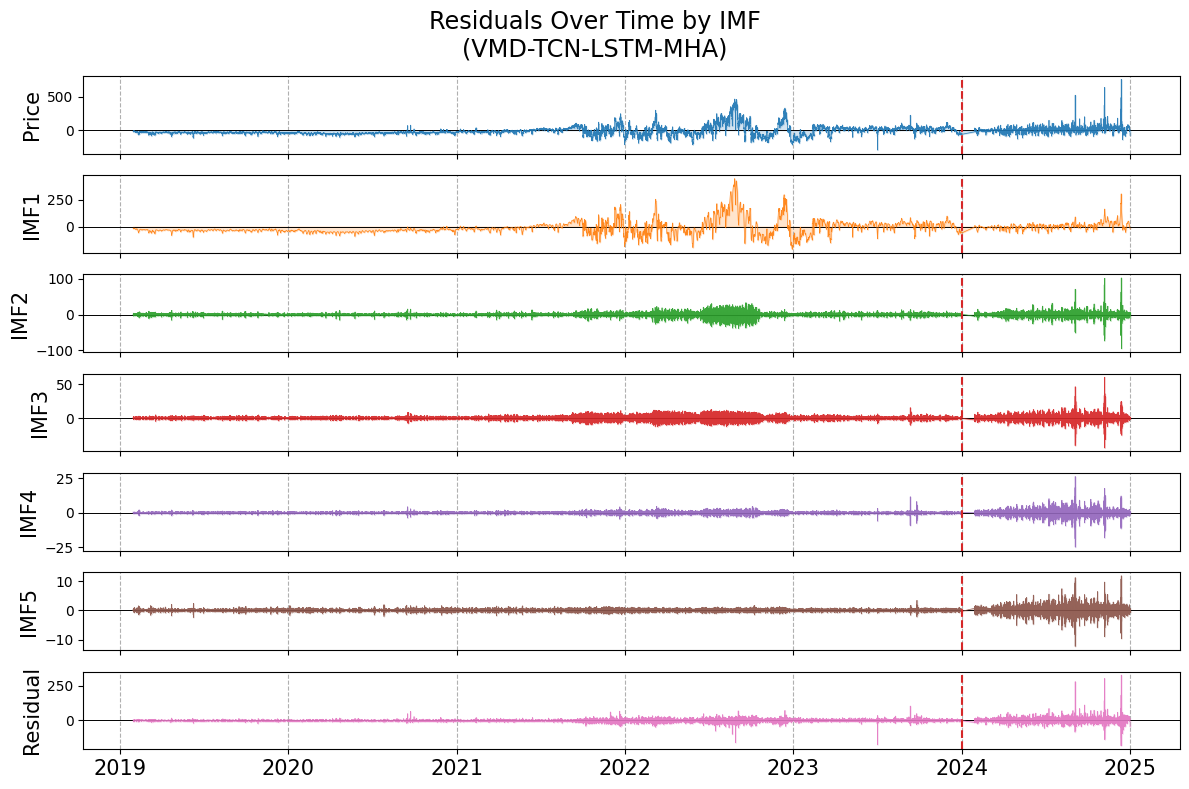

In [6]:
fig, axes = plot_imfs(df_resid)

fig.suptitle('Residuals Over Time by IMF\n(VMD-TCN-LSTM-MHA)', fontsize='xx-large')
for ax in axes:
    ax.axvline(pd.to_datetime('2024-01-01 00:00:00', utc=True), color='tab:red', linestyle='--')
plt.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_imf_resids.svg')
plt.show()

### Recomposed Residuals

#### Actual vs. Predicted

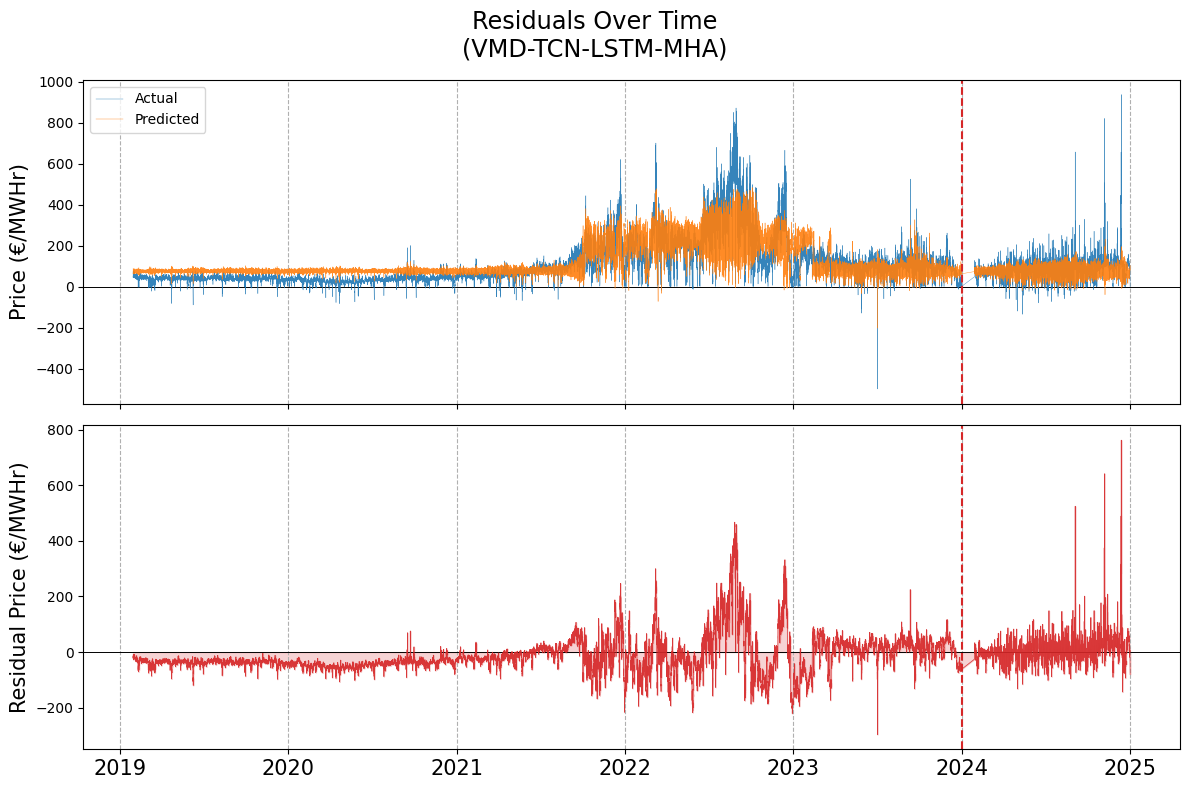

In [7]:
fig, axes = plot_residuals(df_actual=df, df_pred=df_pred)
fig.suptitle('Residuals Over Time\n(VMD-TCN-LSTM-MHA)', fontsize='xx-large')
for ax in axes:
    ax.axvline(pd.to_datetime('2024-01-01 00:00:00', utc=True), color='tab:red', linestyle='--')
plt.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_preds.svg')
plt.show()

In [8]:
evaluate_model(y_true=df_test['price'], y_pred=df_test_pred['price'])

,property,metric,score
0,variance,r2,0.3063
1,variance,wi,0.6485
2,variance,ns,0.3063
3,variance,lm,0.1681
4,variance,kge,0.3047
5,bias,rmse,45.1186
6,bias,mae,28.8425
7,bias,nrmse,0.5734
8,bias,rmae,0.3666
9,bias,smape,0.4942


#### Distribution of Residuals by Day of the Week

In [9]:
df_price_resid = df_test_resid.copy(deep=True)

df_price_resid['day_of_week'] = df_price_resid.index.dayofweek
df_price_resid = df_price_resid.replace({0:'Mon', 1:'Tues', 2:'Wed', 3:'Thurs', 4:'Fri', 5:'Sat', 6:'Sun'})

df_price_resid['hour_of_day'] = df_price_resid.index.hour
df_price_resid['hour_of_day'] = df_price_resid['hour_of_day'].astype('str')

df_price_resid.head()

,imf1,imf2,imf3,imf4,imf5,resid,price,day_of_week,hour_of_day
datetime,,,,,,,,,
2024-01-29 00:00:00+00:00,-5.052993,-4.647468,-2.765374,0.077562,0.710814,-13.858300,-25.535761,Mon,0
2024-01-29 01:00:00+00:00,-4.341297,-3.960585,-0.713068,-0.648424,0.092919,-14.381153,-23.951609,Mon,1
2024-01-29 02:00:00+00:00,-3.536454,-1.248045,0.703207,0.701975,-0.629395,-17.283899,-21.292611,Mon,2
2024-01-29 03:00:00+00:00,-2.582172,1.994872,0.345311,0.984275,0.784699,-15.434084,-13.907091,Mon,3
2024-01-29 04:00:00+00:00,-1.464067,4.597043,0.334004,-0.723978,-0.180109,-13.042710,-10.479810,Mon,4


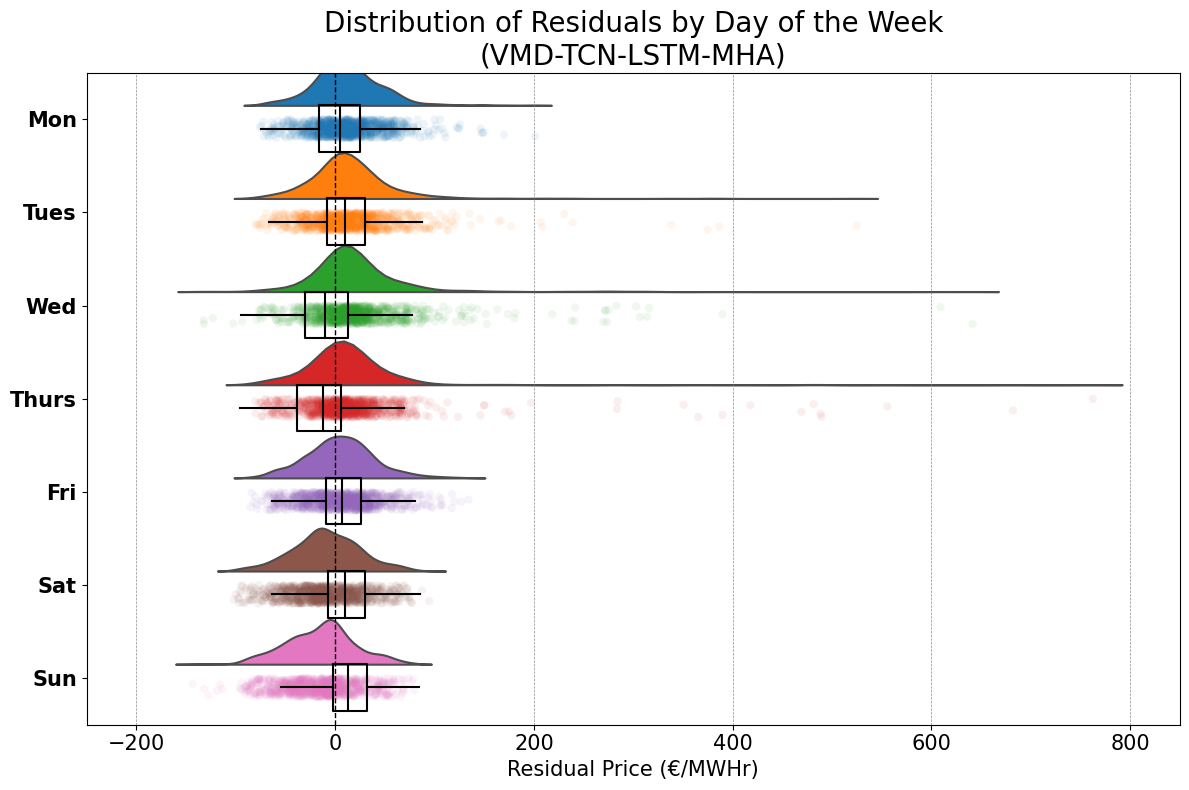

In [10]:
medianprops = {'linewidth':1.5, 'color':'black', 'solid_capstyle':'butt'}
boxprops = {'linewidth':1.5, 'color':'black'}
group_var = 'day_of_week'
GROUPS = df_price_resid[group_var].unique()
COLORS = plt.colormaps['tab10'].colors

fig, ax = plt.subplots(figsize=(12, 8))

for x in [-200, 200, 400, 600, 800]:
    ax.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.9)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

pt.half_violinplot(
    x='price', y=group_var, scale = 'area', 
    palette='tab10', inner=None, data=df_price_resid, width=1,
    ax=ax
)

for i, group in enumerate(GROUPS):
    data = df_price_resid[df_price_resid[group_var] == group]
    y = i + np.random.uniform(high=0.2, size=len(data))
    x = data['price']
    ax.scatter(x, y, color=COLORS[i%len(COLORS)], edgecolors='none', alpha=0.075)

SHIFT = 0.1
POSITIONS = [_+SHIFT for _ in range(len(GROUPS))]
grouped = df_price_resid.groupby(group_var)['price']
data = [group.values for _, group in grouped]

ax.boxplot(
    data, 
    vert=False, 
    positions=POSITIONS, 
    manage_ticks=False,
    showfliers = False,
    showcaps = False,
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops
)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='both', labelsize=15)
ax.set_xlabel('Residual Price (€/MWHr)', fontsize=15)
ax.set_title('Distribution of Residuals by Day of the Week\n(VMD-TCN-LSTM-MHA)', fontsize=20)
fig.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_resid_by_day.svg')
plt.show()

#### Distribution of Residuals by Hour of the Day

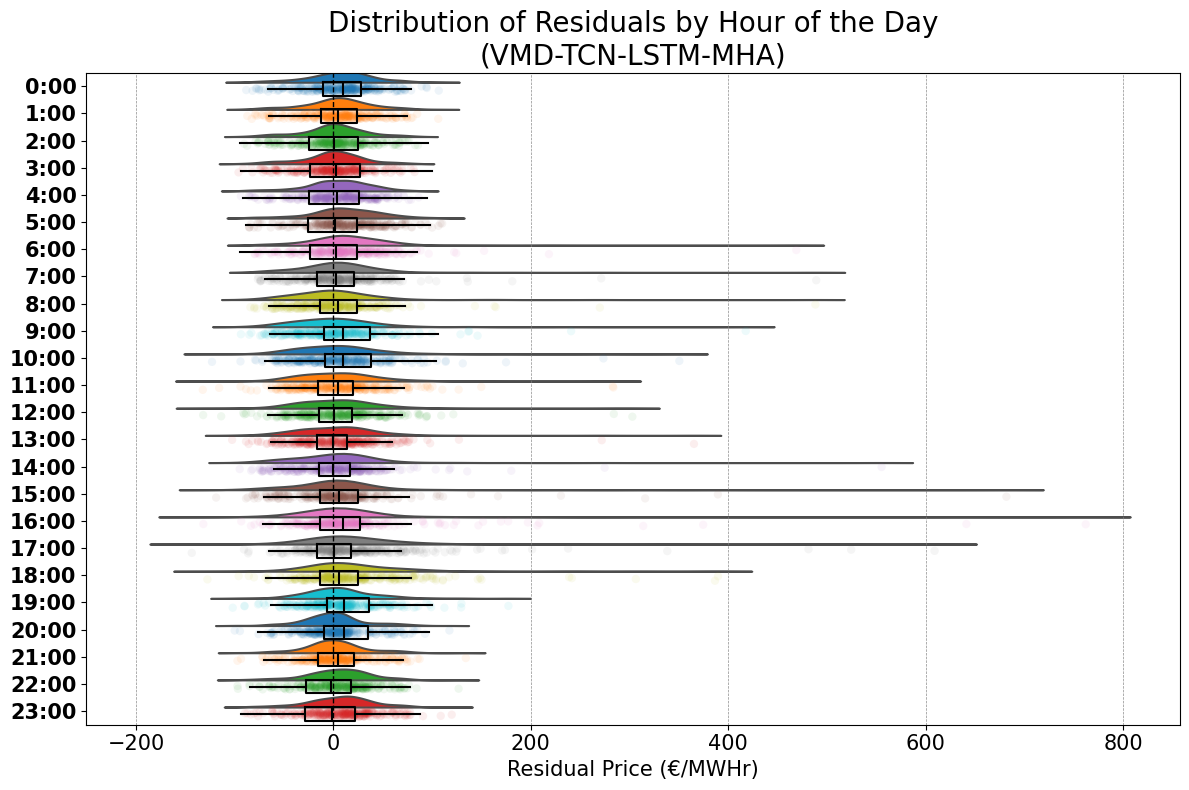

In [11]:
medianprops = {'linewidth':1.5, 'color':'black', 'solid_capstyle':'butt'}
boxprops = {'linewidth':1.5, 'color':'black'}
group_var = 'hour_of_day'
GROUPS = df_price_resid[group_var].unique()
COLORS = plt.colormaps['tab10'].colors

fig, ax = plt.subplots(figsize=(12, 8))

for x in [-200, 200, 400, 600, 800]:
    ax.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.9)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

pt.half_violinplot(
    x='price', y=group_var, scale = 'area', 
    palette='tab10', inner=None, data=df_price_resid, width=1,
    ax=ax
)

for i, group in enumerate(GROUPS):
    data = df_price_resid[df_price_resid[group_var] == group]
    y = i + np.random.uniform(high=0.2, size=len(data))
    x = data['price']
    ax.scatter(x, y, color=COLORS[i%len(COLORS)], edgecolors='none', alpha=0.075)

SHIFT = 0.1
POSITIONS = [_+SHIFT for _ in range(len(GROUPS))]
grouped = df_price_resid.groupby(group_var)['price']
data = [group.values for _, group in grouped]

ax.boxplot(
    data, 
    vert=False, 
    positions=POSITIONS, 
    manage_ticks=False,
    showfliers = False,
    showcaps = False,
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops
)

ax.set_yticklabels([str(t)+':00' for t in range(0, 24)])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='both', labelsize=15)
ax.set_xlabel('Residual Price (€/MWHr)', fontsize=15)
ax.set_title('Distribution of Residuals by Hour of the Day\n(VMD-TCN-LSTM-MHA)', fontsize=20)
fig.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_resid_by_hour.svg')
plt.show()

#### ACF/PACF of Squared Residuals

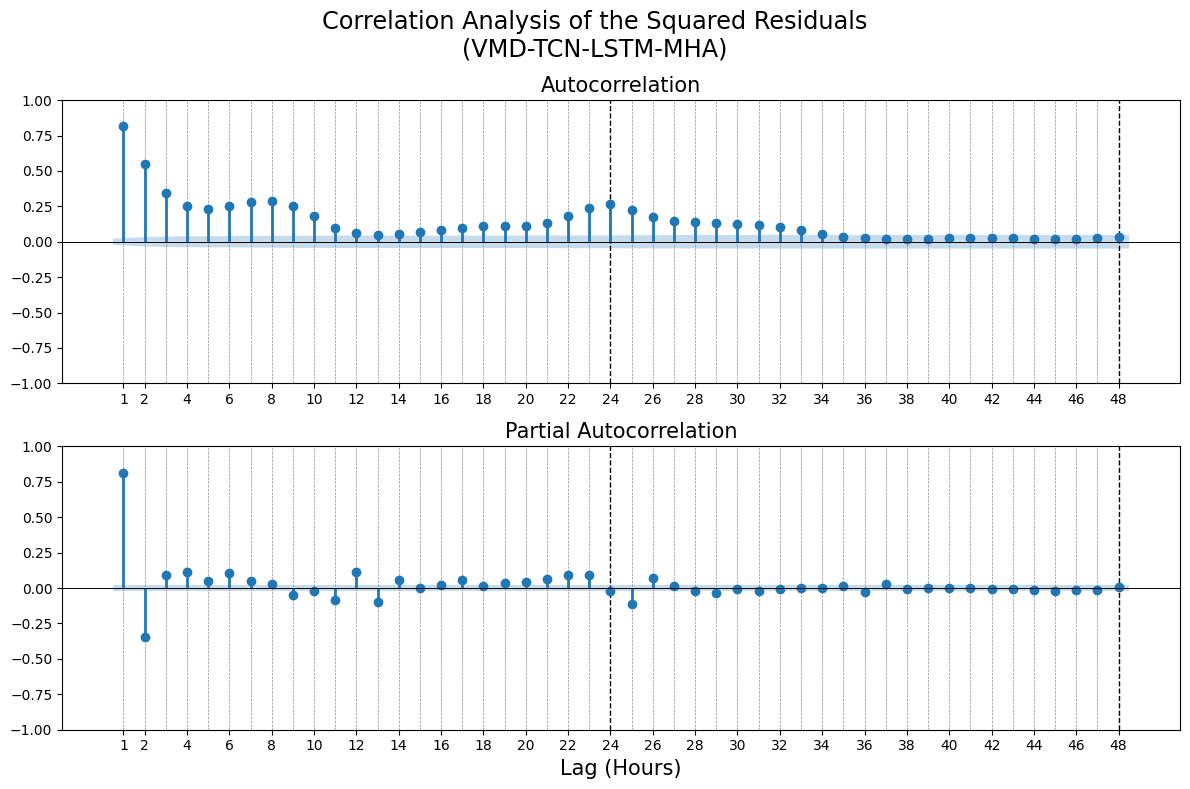

In [12]:
fig, _ = plot_sqresid(df_test_resid)

fig.suptitle('Correlation Analysis of the Squared Residuals\n(VMD-TCN-LSTM-MHA)', fontsize='xx-large')
fig.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_acf_pacf_sq_resids.svg')
plt.show()